In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [29]:
df = pd.read_csv(r"C:\Users\HP\Desktop\MLR\Student_Performance (1).csv")

In [30]:
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [31]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [32]:
df.shape

(10000, 6)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [34]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [35]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [36]:
df.duplicated().sum()

127

In [37]:
df.drop_duplicates()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [39]:
df = pd.get_dummies(df,drop_first= True)

In [40]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730,0.003873
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189,0.008369
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106,-0.023284
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268,0.013103
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000,0.024525
Extracurricular Activities_Yes,0.003873,0.008369,-0.023284,0.013103,0.024525,1.000000


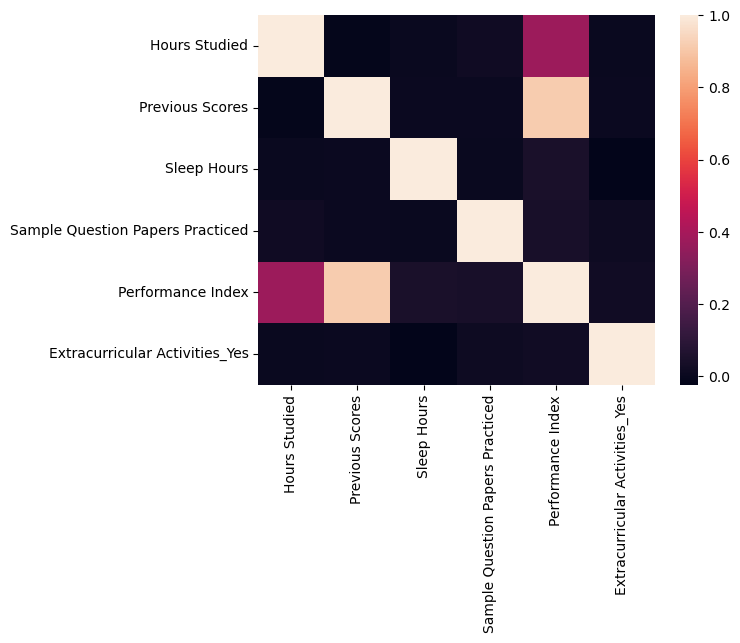

In [42]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

In [43]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index',
       'Extracurricular Activities_Yes'],
      dtype='object')

In [19]:
#df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
#    "Yes": 1,
#    "No": 0
#})

In [45]:
# fetures
x = df[['Hours Studied','Previous Scores','Extracurricular Activities_Yes','Sleep Hours','Sample Question Papers Practiced']]
y = df['Performance Index']

In [46]:
model = LinearRegression()

In [47]:
# x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
#import statsmodels.api as sm
#x = sm.add_constant(x)
#model = sm.OLS(y,x).fit()
#print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Performance Index   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.757e+05
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        10:33:44   Log-Likelihood:                -21307.
No. Observations:               10000   AIC:                         4.263e+04
Df Residuals:                    9994   BIC:                         4.267e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [48]:
model.fit(x_train, y_train)

LinearRegression()

In [70]:
import pickle

with open('prediction.pkl', 'wb') as f:
    pickle.dump(model, f)


In [72]:
with open('prediction.pkl','rb') as f:
    model = pickle.load(f)

In [73]:
predictions = model.predict(x_test)

In [74]:
model.coef_

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

In [75]:
model.intercept_

-33.92194621555631

In [57]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [76]:
mean_absolute_error(y_test,predictions)
# On average the model's prediction is off from the actual scores by 1.611 marks

1.6111213463123044

In [77]:
mean_squared_error(y_test,predictions)
# 

4.082628398521854

In [78]:
np.sqrt(mean_squared_error(y_test,predictions))
# The model's predictions are typically 2.021 way from the true scores

2.020551508505006

In [79]:
r2_score(y_test,predictions)
# (0.989 out of 1) shows that the variation in the scores are explained by the model

0.9889832909573145

In [80]:
model.predict(x_test)

array([54.71185392, 22.61551294, 47.90314471, ..., 16.79341955,
       63.34327368, 45.94262301])

In [81]:
predictions[:5]

array([54.71185392, 22.61551294, 47.90314471, 31.28976748, 43.00457042])

In [66]:
import sklearn
print(sklearn.__version__)

1.4.2
